
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

Primero realizo como base el ejercicio con 10 Nodos

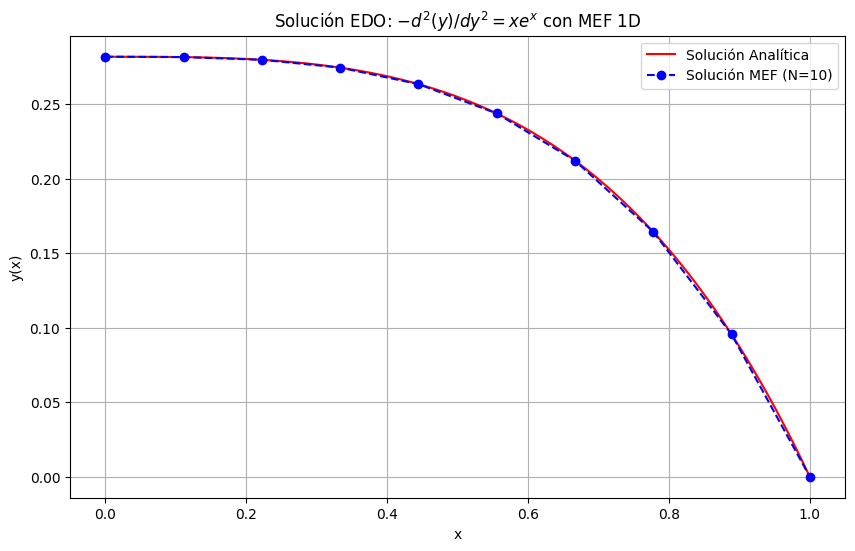

In [ ]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

def fem_1d(f, a, b, y_a, y_b, N):
    xi = np.linspace(a, b, N)
    A = np.zeros((N, N))
    b_vec = np.zeros(N)

    # Ensamblaje de la matriz de rigidez y vector de carga
    for i in range(1, N):
        h_e = xi[i] - xi[i-1]

        # Matriz elemental
        A[i-1, i-1] += 1.0 / h_e
        A[i-1, i]   -= 1.0 / h_e
        A[i, i-1]   -= 1.0 / h_e
        A[i, i]     += 1.0 / h_e

        # Integracion numerica - vector de carga
        I_left, _  = integrate.quad(lambda x: f(x) * (xi[i] - x) / h_e, xi[i-1], xi[i])
        I_right, _ = integrate.quad(lambda x: f(x) * (x - xi[i-1]) / h_e, xi[i-1], xi[i])

        b_vec[i-1] += I_left
        b_vec[i]   += I_right

    # Condiciones de Dirichlet
    A_p = A.copy()
    b_p = b_vec.copy()

    # Ajuste del vector de carga por los valores de frontera
    for i in range(N):
        b_p[i] -= A[i, 0] * y_a + A[i, N-1] * y_b

    # Aislamiento de los nodos de frontera en la matriz
    A_p[0, :] = 0; A_p[:, 0] = 0; A_p[0, 0] = 1.0; b_p[0] = y_a
    A_p[N-1, :] = 0; A_p[:, N-1] = 0; A_p[N-1, N-1] = 1.0; b_p[N-1] = y_b

    y_sol = np.linalg.solve(A_p, b_p)
    return xi, y_sol

# Parámetros del problema
f_func = lambda x: x * np.exp(x)
a, b = 0.0, 1.0
y_a = 3.0 - np.e
y_b = 0.0
N_nodos = 10  # Aumentado a 10 para notar bien los puntos de la lineal

# Resolución
x_nodos, y_mef = fem_1d(f_func, a, b, y_a, y_b, N_nodos)

# Solución Analítica Verificada
y_exacto = lambda x: np.exp(x) * (2.0 - x) - x + (1.0 - np.e)
x_fine = np.linspace(a, b, 200)

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(x_fine, y_exacto(x_fine), 'r-', label='Solución Analítica')
plt.plot(x_nodos, y_mef, 'bo--', label=f'Solución MEF (N={N_nodos})')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title(r'Solución EDO: $-d^2(y)/dy^2 = x e^x$ con MEF 1D')
plt.grid(True)
plt.legend()
plt.show()

Ahora comparamos el caso con diferente numero de nodos

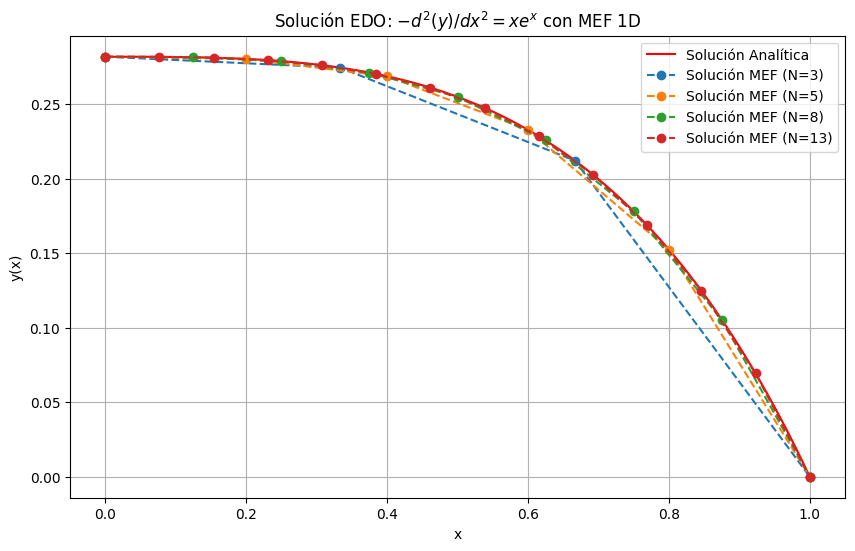

In [ ]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

def fem_1d(f, a, b, y_a, y_b, N):
    xi = np.linspace(a, b, N + 1)
    A = np.zeros((N + 1, N + 1))
    b_vec = np.zeros(N + 1)

    # Ensamblaje de la matriz de rigidez y vector de carga
    for i in range(1, N + 1):
        h_e = xi[i] - xi[i-1]

        # Matriz elemental
        A[i-1, i-1] += 1.0 / h_e
        A[i-1, i]   -= 1.0 / h_e
        A[i, i-1]   -= 1.0 / h_e
        A[i, i]     += 1.0 / h_e

        # Integracion numerica - vector de carga
        I_left, _  = integrate.quad(lambda x: f(x) * (xi[i] - x) / h_e, xi[i-1], xi[i])
        I_right, _ = integrate.quad(lambda x: f(x) * (x - xi[i-1]) / h_e, xi[i-1], xi[i])

        b_vec[i-1] += I_left
        b_vec[i]   += I_right

    # Condiciones de Dirichlet
    A_p = A.copy()
    b_p = b_vec.copy()

    # Ajuste del vector de carga por los valores de frontera
    for i in range(N + 1):
        b_p[i] -= A[i, 0] * y_a + A[i, N] * y_b

    # Aislamiento de los nodos de frontera en la matriz
    A_p[0, :] = 0; A_p[:, 0] = 0; A_p[0, 0] = 1.0; b_p[0] = y_a
    A_p[N, :] = 0; A_p[:, N] = 0; A_p[N, N] = 1.0; b_p[N] = y_b

    y_sol = np.linalg.solve(A_p, b_p)
    return xi, y_sol

# Parámetros del problema
f_func = lambda x: x * np.exp(x)
a, b = 0.0, 1.0
y_a = 3.0 - np.e
y_b = 0.0

# Número de elementos
N_valores = [3, 5, 8, 13]

# Solución Analítica
y_exacto = lambda x: np.exp(x) * (2.0 - x) - x + (1.0 - np.e)
x_fine = np.linspace(a, b, 200)

# Gráfica
plt.figure(figsize=(10, 6))

plt.plot(x_fine, y_exacto(x_fine), 'r-', label='Solución Analítica')

for N in N_valores:
    x_nodos, y_mef = fem_1d(f_func, a, b, y_a, y_b, N)

    plt.plot(x_nodos, y_mef, 'o--', label=f'Solución MEF (N={N})')

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title(r'Solución EDO: $-d^2(y)/dx^2 = x e^x$ con MEF 1D')
plt.grid(True)
plt.legend()
plt.show()